# EfficientNet-B3 (Basic)

## Changes from EfficientNet-B3 Augmented

### What changed
| | EfficientNet-B3 Augmented | EfficientNet-B3 Basic |
|---|---|---|
| Augmentation | Strong (v-flip, ±30°, ColorJitter, RandomAffine) | Basic (h-flip, ±10° rotation) |
| Optimizer | AdamW | Adam |
| Weight decay | 1e-4 | None |
| LR scheduler | CosineAnnealingLR | None |

### Rationale
Every regularisation experiment (aug v1, aug v2, EfficientNet augmented) has consistently hurt recall compared to the plain ResNet unfreeze baseline. The hypothesis is that augmentation and weight decay make training harder and constrain the model too aggressively on this small dataset (~7,800 images), specifically hurting recall on the subtle visual patterns of melanoma.

This notebook applies the ResNet unfreeze recipe to EfficientNet-B3 — if the architecture is genuinely stronger, it should show without regularisation getting in the way.

In [14]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [ ]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [15]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [16]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV (label=0 → inverted to 1)
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV (label=1 → inverted to 0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_efficientnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([6.0244], device='mps:0')


In [17]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/efficientnet_b3_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8097, Acc: 0.7361, Recall: 0.8524, F2: 0.6498 | Val Loss: 0.6169, Acc: 0.7656, Recall: 0.9281, F2: 0.7136
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.5637, Acc: 0.8332, Recall: 0.8832, F2: 0.7436 | Val Loss: 0.6026, Acc: 0.8167, Recall: 0.8443, F2: 0.7064


Epoch [3/20] | Train Loss: 0.4328, Acc: 0.8734, Recall: 0.9191, F2: 0.8023 | Val Loss: 0.5983, Acc: 0.8670, Recall: 0.7964, F2: 0.7205
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.3474, Acc: 0.9000, Recall: 0.9422, F2: 0.8433 | Val Loss: 0.6184, Acc: 0.8184, Recall: 0.8623, F2: 0.7186


Epoch [5/20] | Train Loss: 0.2973, Acc: 0.9254, Recall: 0.9435, F2: 0.8719 | Val Loss: 0.6433, Acc: 0.8986, Recall: 0.7784, F2: 0.7386
Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.0630, Acc: 0.9850, Recall: 0.9884, F2: 0.9725 | Val Loss: 1.0430, Acc: 0.9156, Recall: 0.7485, F2: 0.7353


Epoch [17/20] | Train Loss: 0.0515, Acc: 0.9887, Recall: 0.9936, F2: 0.9805 | Val Loss: 1.0856, Acc: 0.9207, Recall: 0.7126, F2: 0.7151


Epoch [18/20] | Train Loss: 0.0578, Acc: 0.9868, Recall: 0.9872, F2: 0.9742 | Val Loss: 1.3181, Acc: 0.9284, Recall: 0.7186, F2: 0.7273


Epoch [19/20] | Train Loss: 0.0494, Acc: 0.9865, Recall: 0.9910, F2: 0.9760 | Val Loss: 1.1451, Acc: 0.9147, Recall: 0.7485, F2: 0.7344


Epoch [20/20] | Train Loss: 0.0632, Acc: 0.9859, Recall: 0.9884, F2: 0.9737 | Val Loss: 1.0581, Acc: 0.9003, Recall: 0.7844, F2: 0.7443


## Plot Loss and Accuracy Curves

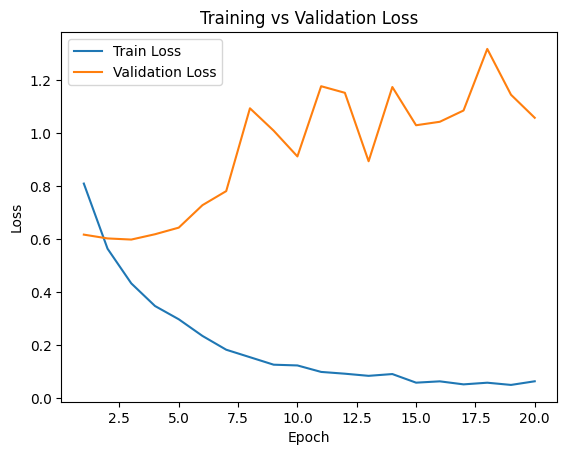

In [18]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

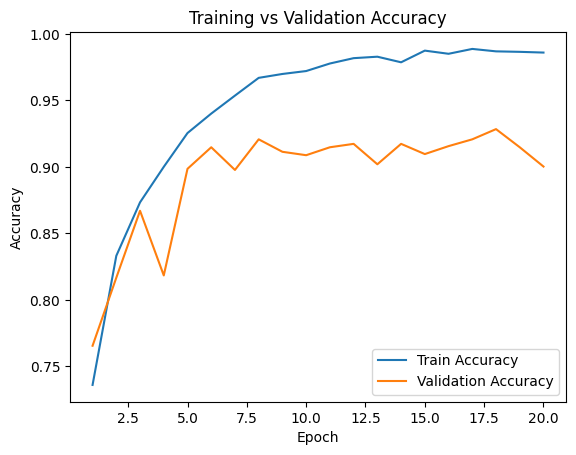

In [19]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

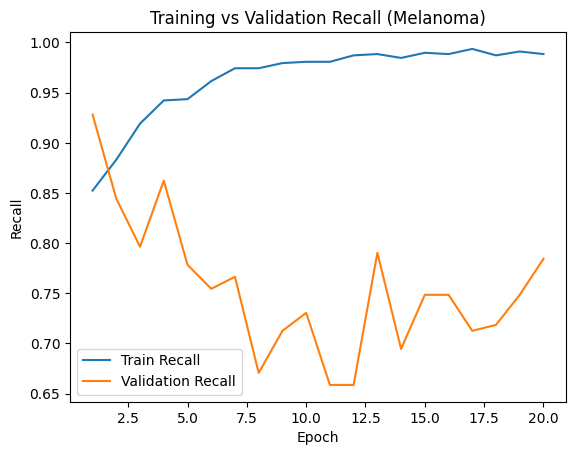

In [20]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

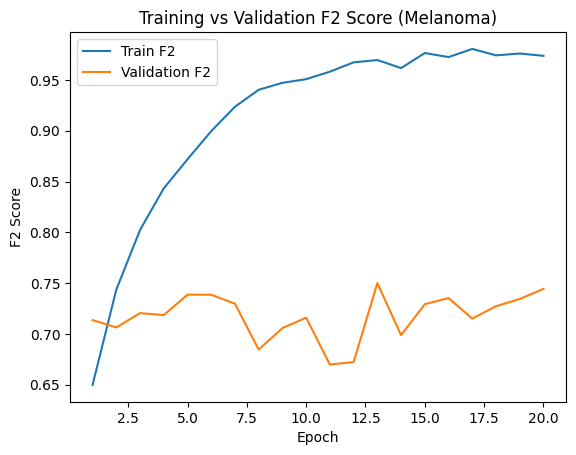

In [21]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [22]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('../models/efficientnet_b3_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.24 | Val F2: 0.7726


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [24]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[903 103]
 [ 24 143]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [25]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9741    0.8976    0.9343      1006
           1     0.5813    0.8563    0.6925       167

    accuracy                         0.8917      1173
   macro avg     0.7777    0.8770    0.8134      1173
weighted avg     0.9182    0.8917    0.8999      1173



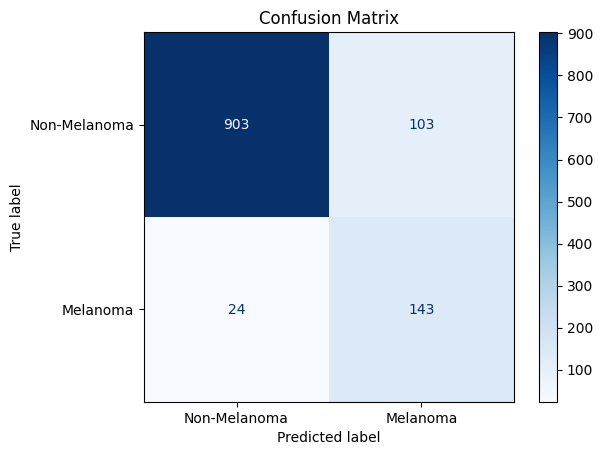

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()